In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
import pandas as pd
data = pd.read_csv('default.csv')
data = data.dropna()
data.head()

,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879


In [27]:
X = data['balance']
Y = data['student']
data.head()

,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879


In [28]:
X,Y

(0       729.526495
 1       817.180407
 2      1073.549164
 3       529.250605
 4       785.655883
           ...     
 995     731.951715
 996     717.810768
 997    1005.176223
 998     561.928361
 999    2033.191790
 Name: balance, Length: 1000, dtype: float64,
 0      0
 1      1
 2      0
 3      0
 4      0
       ..
 995    1
 996    0
 997    1
 998    0
 999    0
 Name: student, Length: 1000, dtype: int64)

In [29]:
catColumns = data.select_dtypes(['object']).columns
catColumns




Index([], dtype='object')

In [30]:
data = pd.get_dummies(data)
data

,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879
...,...,...,...,...
995,0,1,731.951715,18117.427911
996,0,0,717.810768,32040.931260
997,0,1,1005.176223,18262.176143
998,0,0,561.928361,31192.912724


In [31]:
model = LogisticRegression()
model.fit(np.reshape(X, newshape = (-1,1)), Y)
print("Coefficent =",model.coef_)
print("Constant(c) =",model.intercept_)

Coefficent = [[0.00114674]]
Constant(c) = [-1.83437903]


In [32]:
x_new = [[10000]]
y_pred = model.predict(x_new)
print("Balance:",x_new[0])
Class = {1:'Yes', 0 : 'No'}
print("Is He Student?:", Class[y_pred[0]])

Balance: [10000]
Is He Student?: Yes


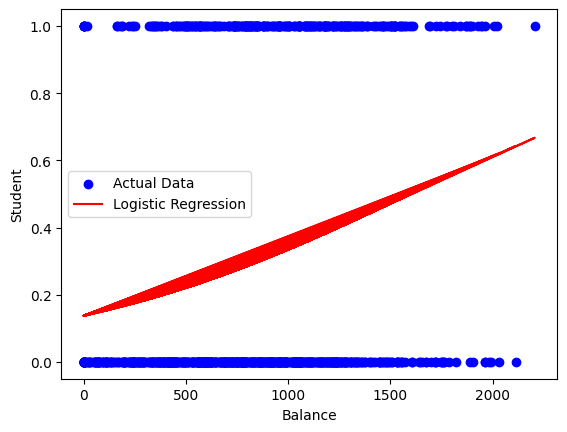

In [37]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, model.predict_proba(np.reshape(X.to_list(), newshape=(-1,1)))[:, 1], color='red', label='Logistic Regression')
plt.xlabel('Balance')
plt.ylabel('Student')
plt.legend()
plt.show()